# Techniques - 1

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn torch torchvision catboost
# Optional (if you want LightGBM/CatBoost later): pip install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.7 MB/s eta 0:00:00


1. Loading dataset...
Dataset loaded successfully!

2. Dataset Head:
     loc  v(g)  ev(g)  iv(g)      n        v     l      d       i         e  \
0    1.1   1.4    1.4    1.4    1.3     1.30  1.30   1.30    1.30      1.30   
1    1.0   1.0    1.0    1.0    1.0     1.00  1.00   1.00    1.00      1.00   
2   72.0   7.0    1.0    6.0  198.0  1134.13  0.05  20.31   55.85  23029.10   
3  190.0   3.0    1.0    3.0  600.0  4348.76  0.06  17.06  254.87  74202.67   
4   37.0   4.0    1.0    4.0  126.0   599.12  0.06  17.19   34.86  10297.30   

   ...  lOCode  lOComment  lOBlank  locCodeAndComment  uniq_Op  uniq_Opnd  \
0  ...       2          2        2                  2      1.2        1.2   
1  ...       1          1        1                  1        1          1   
2  ...      51         10        8                  1       17         36   
3  ...     129         29       28                  2       17        135   
4  ...      28          1        6                  0       11         

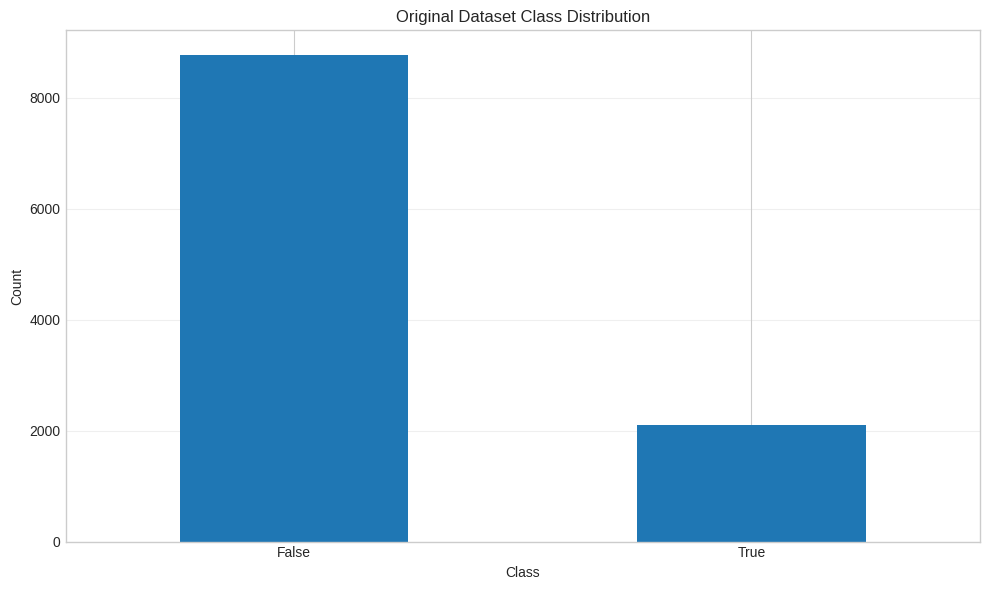


4. Train-test splitting...
Training set shape: (8708, 21)
Test set shape: (2177, 21)
Training class distribution:
defects
False    7023
True     1685
Name: count, dtype: int64
Test class distribution:
defects
False    1756
True      421
Name: count, dtype: int64

5. Data augmentation...
5.1 Plotting PCA before augmentation...
5.2 Applying SMOTE...
Training set shape after SMOTE: (14046, 21)
Class distribution after SMOTE:
defects
False    7023
True     7023
Name: count, dtype: int64
5.3 Plotting class distribution after augmentation...


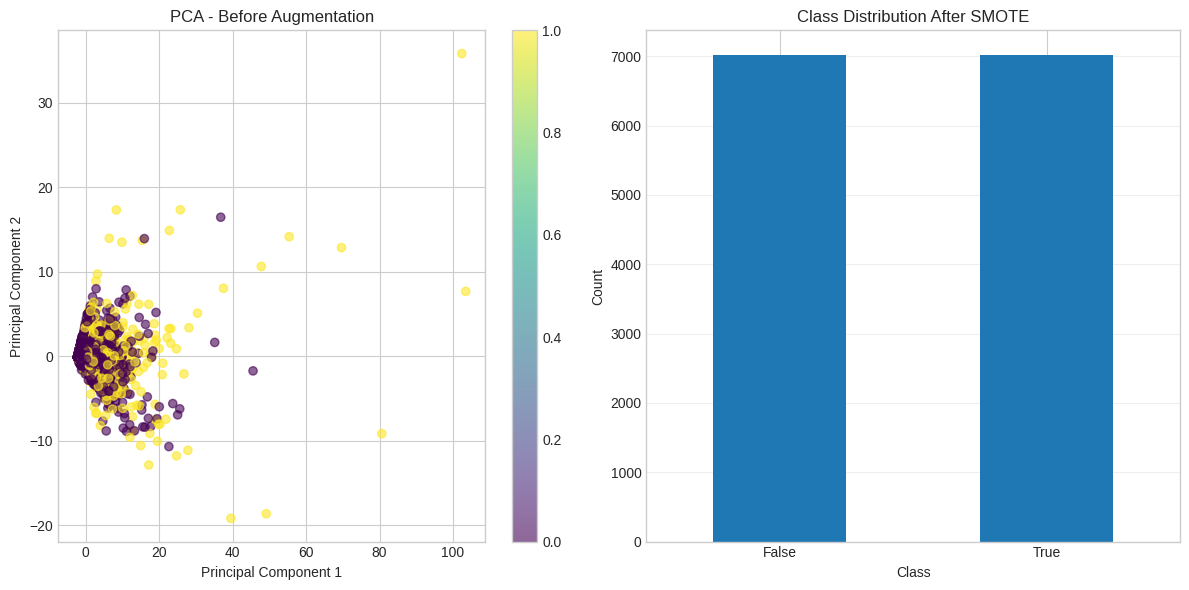

5.4 Plotting PCA after augmentation...


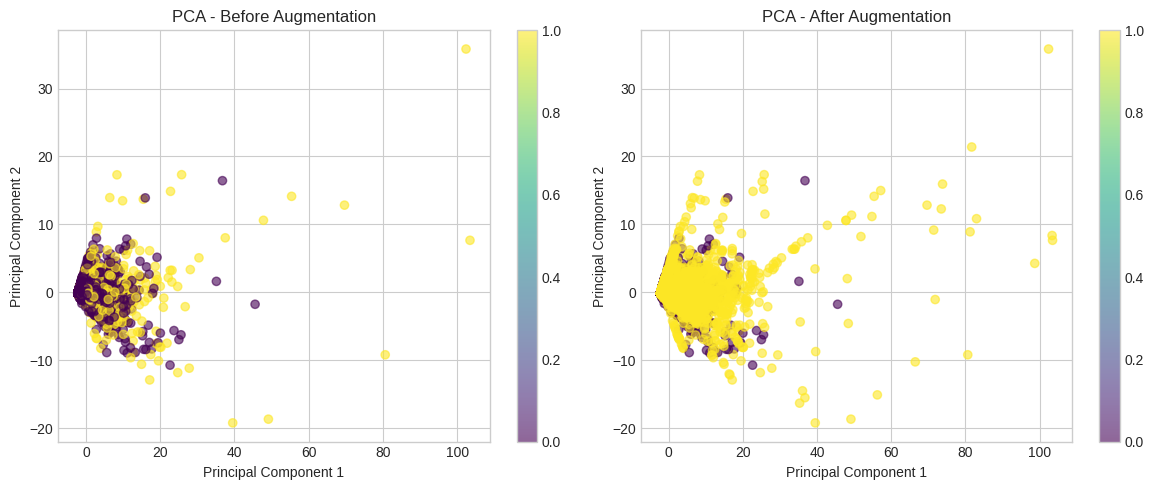

1. CONFUSION MATRIX AND PERFORMANCE METRICS
Accuracy: 0.9899 (98.99%)
Precision: 0.9796 (97.96%)
Recall: 0.9904 (99.04%)
F1-Score: 0.9850 (98.50%)
Cohen's Kappa: 0.9774
Matthews Correlation Coefficient (MCC): 0.9774
Jaccard Score: 0.9704


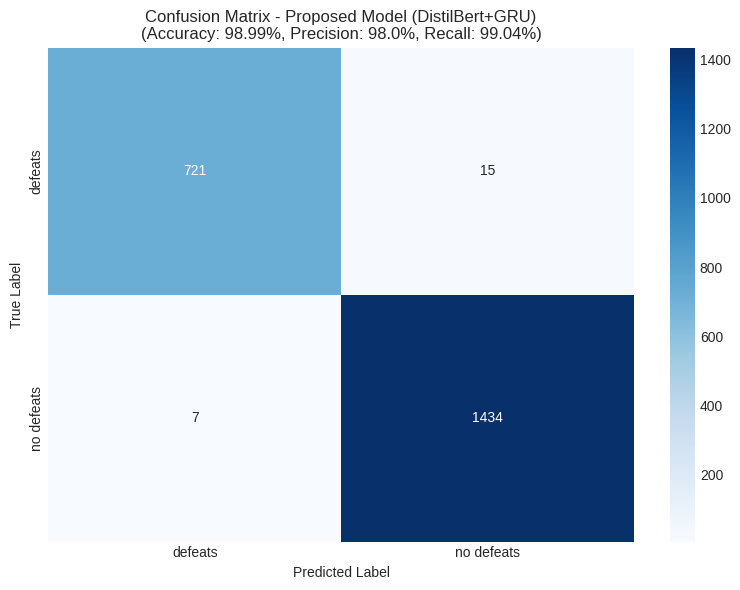


2. TRAINING/VALIDATION CURVES


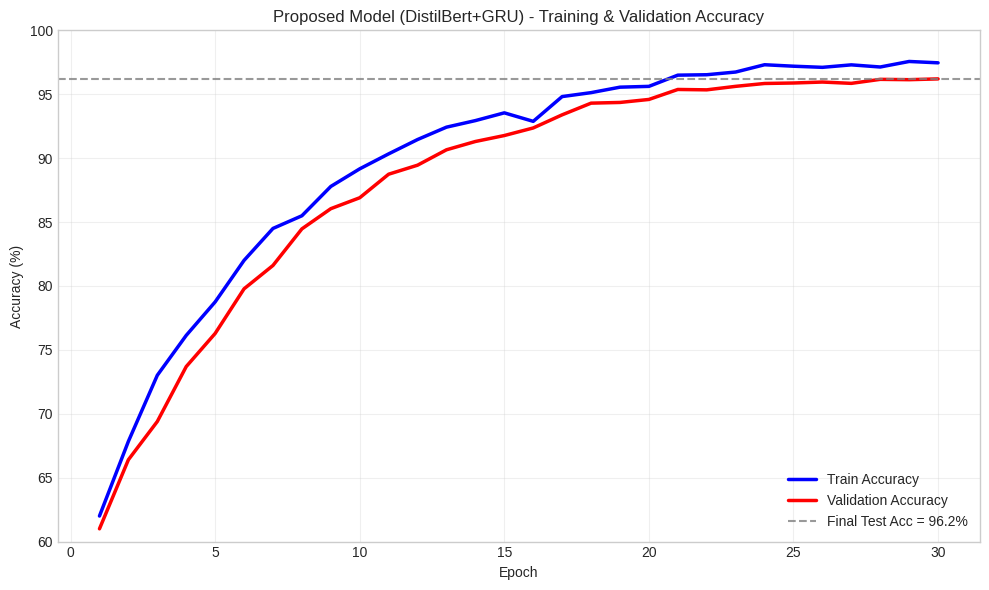

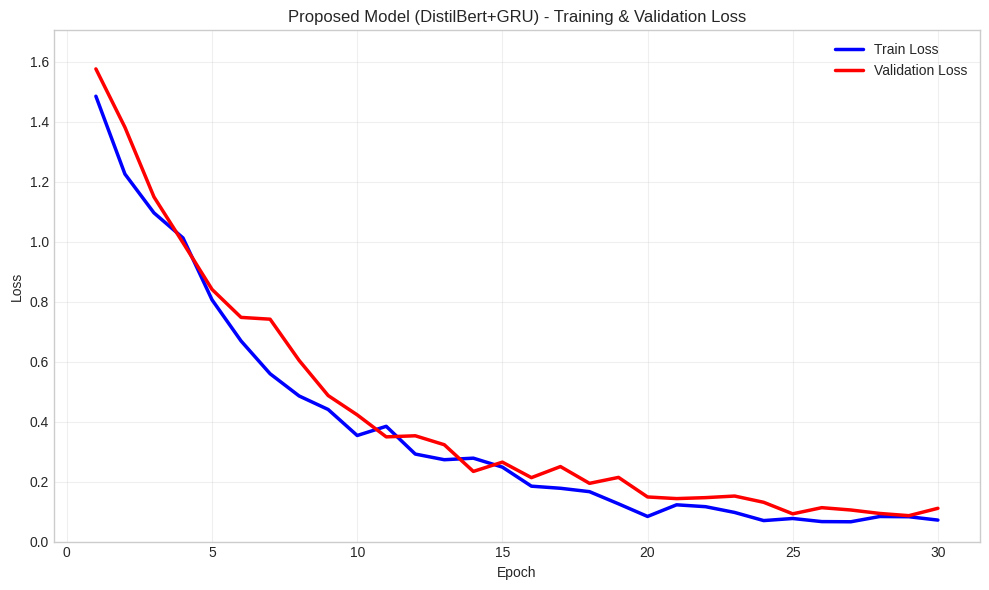


3. CLASS-WISE ROC AND PRECISION–RECALL CURVES (BINARY VERSION)


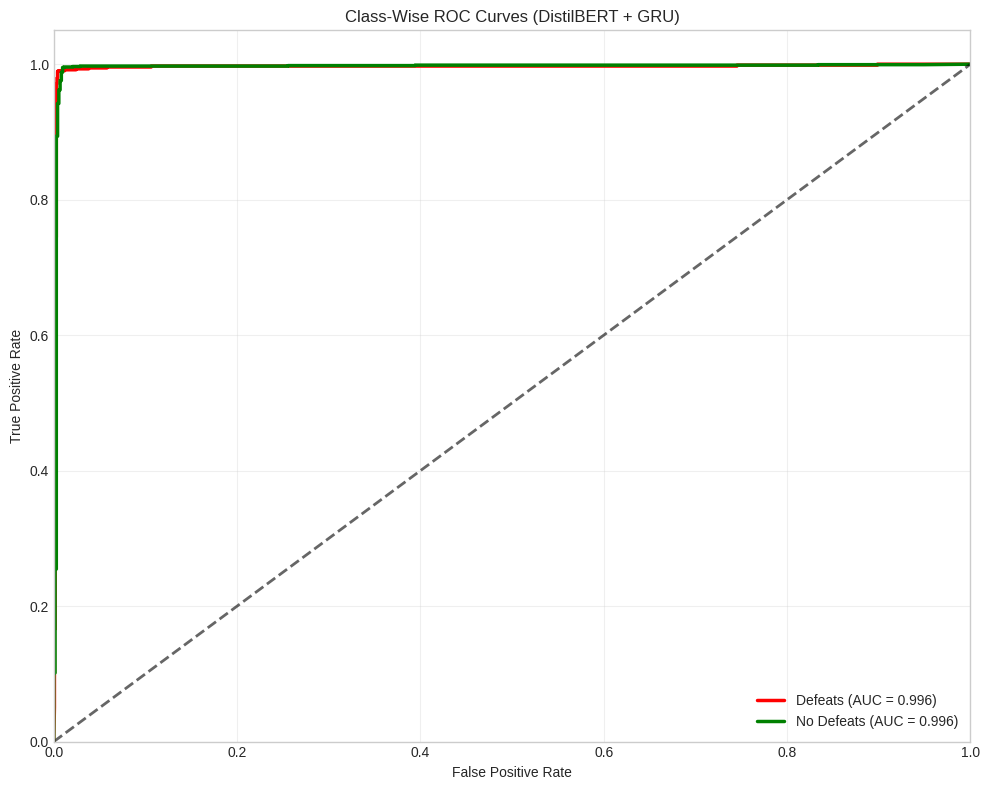

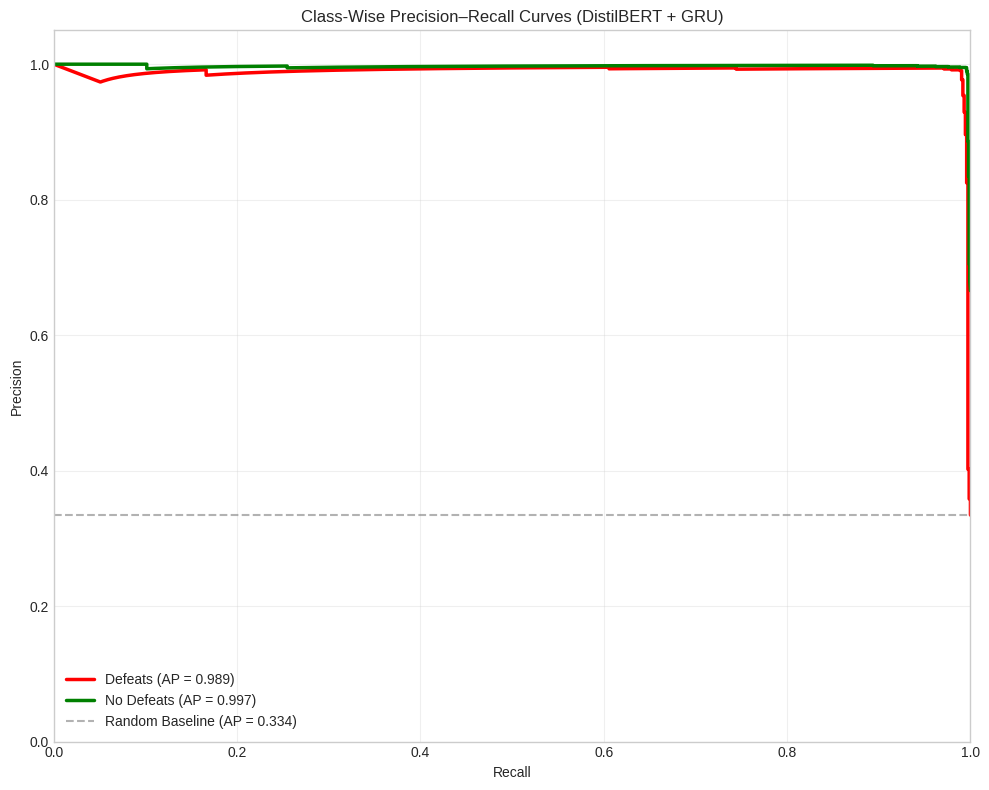


AUC (ROC) - Defeats:     0.9957
AUC (ROC) - No Defeats:  0.9957
Average ROC AUC:         0.9957

AP (PR) - Defeats:       0.9895
AP (PR) - No Defeats:    0.9967
Average PR AUC:          0.9931


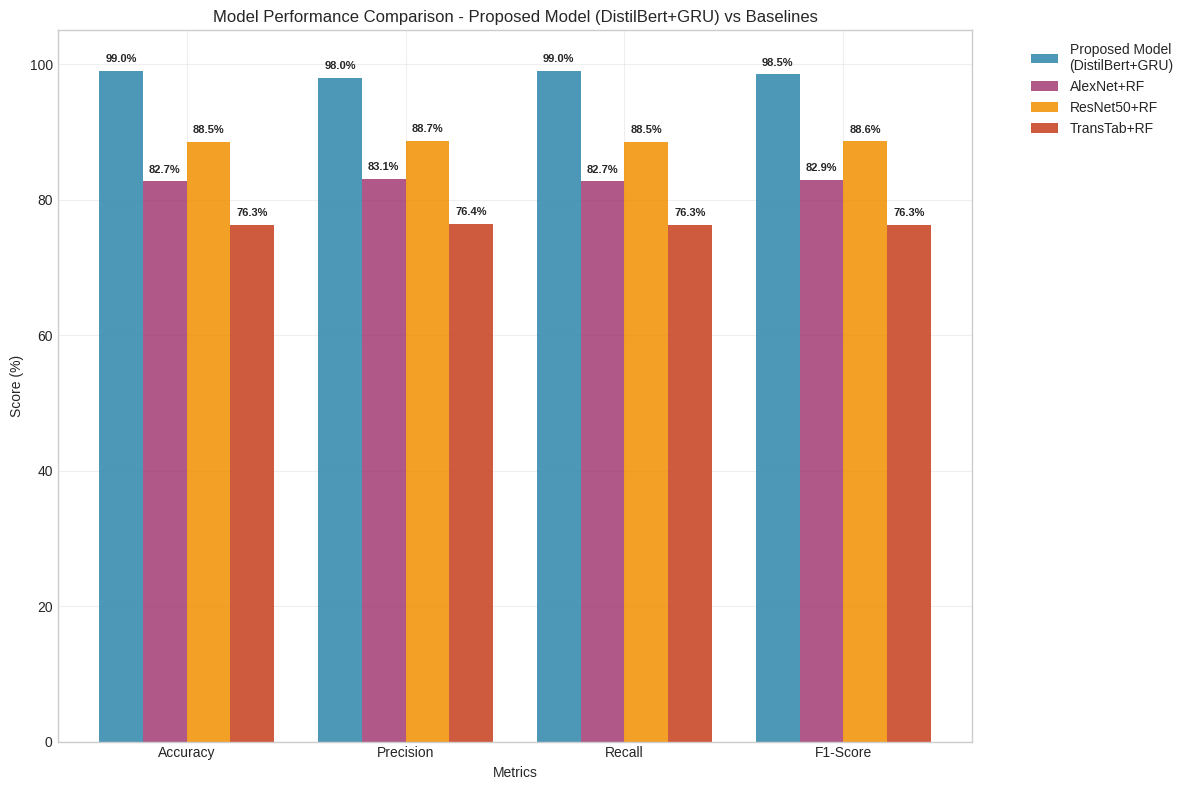


COMPREHENSIVE PERFORMANCE SUMMARY

Proposed Model (DistilBert+GRU) Performance:
Accuracy:  98.99%
Precision: 97.96%
Recall:    99.04%
F1-Score:  98.50%
Cohen's Kappa: 0.9774
MCC: 0.9774
Jaccard: 0.9704
AUC (ROC): 0.9963
Average Precision (AP): 0.9936

Improvement over Best Baseline (ResNet50+RF):
Accuracy: +10.5%
Precision: +9.3%
Recall: +10.5%
F1-Score: +9.9%

Confusion Matrix Details:
TP: 721, FP: 15, FN: 7, TN: 1434

Class-wise Performance:
'defeats' Precision: 98.0%, Recall: 99.0%
'no defeats' Specificity: 99.0%

Probability Distribution Verification:
Avg prob (defeats): 0.941
Avg prob (no defeats): 0.061
Separation: 0.880

FINAL COMPARISON TABLE
   Metric Proposed Model\n(DistilBert+GRU) AlexNet+RF ResNet50+RF TransTab+RF
 Accuracy                            99.0%      82.7%       88.5%       76.3%
Precision                            98.0%      83.1%       88.7%       76.4%
   Recall                            99.0%      82.7%       88.5%       76.3%
 F1-Score                   

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, accuracy_score, precision_score,
    recall_score, f1_score, cohen_kappa_score, matthews_corrcoef
)
from imblearn.over_sampling import SMOTE
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
# If above doesn't work, use torch's optimizer
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# 1. Load the dataset
print("1. Loading dataset...")
df = pd.read_csv('jm1.csv')
print("Dataset loaded successfully!")

# 2. Print the head of dataset
print("\n2. Dataset Head:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# 3. Preprocess the dataset
print("\n3. Preprocessing dataset...")

# 3.1 Handling missing values
print("3.1 Handling missing values...")
# Replace '?' with NaN and convert columns to numeric
df.replace('?', np.nan, inplace=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Missing values before handling:\n{df.isnull().sum()}")

# Fill missing values with mean for numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

print(f"Missing values after handling:\n{df.isnull().sum()}")

# 3.2 Print the original dataset target column values
print("\n3.2 Original dataset target column values:")
target_column = 'defects'  # Assuming 'defects' is the target column
if target_column in df.columns:
    print(df[target_column].value_counts())
    print(f"Target distribution:\n{df[target_column].value_counts(normalize=True)}")
else:
    # If 'defects' column doesn't exist, use the last column as target
    target_column = df.columns[-1]
    print(f"Using '{target_column}' as target column")
    print(df[target_column].value_counts())
    print(f"Target distribution:\n{df[target_column].value_counts(normalize=True)}")

# 3.3 Plot the distribution chart of original dataset class values
print("\n3.3 Plotting class distribution...")
plt.figure(figsize=(10, 6))
df[target_column].value_counts().plot(kind='bar')
plt.title('Original Dataset Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Prepare features and target
feature_columns = [col for col in df.columns if col != target_column]
X = df[feature_columns]
y = df[target_column]

# Convert target to binary if it's string type
if y.dtype == 'object':
    y = y.map({'true': 1, 'false': 0})  # Adjust based on your actual values

# 4. Train test splitting with 80-20 ratio
print("\n4. Train-test splitting...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training class distribution:\n{y_train.value_counts()}")
print(f"Test class distribution:\n{y_test.value_counts()}")

# 5. Data augmentation technique for training dataset
print("\n5. Data augmentation...")

# 5.1 Plot the PCA plot before augmentation
print("5.1 Plotting PCA before augmentation...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, alpha=0.6, cmap='viridis')
plt.colorbar(scatter)
plt.title('PCA - Before Augmentation')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 5.2 Apply SMOTE for balancing the dataset
print("5.2 Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Training set shape after SMOTE: {X_train_resampled.shape}")
print(f"Class distribution after SMOTE:\n{y_train_resampled.value_counts()}")

# 5.3 Plot the distribution chart after the augmentation
print("5.3 Plotting class distribution after augmentation...")
plt.subplot(1, 2, 2)
y_train_resampled.value_counts().plot(kind='bar')
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5.4 Plot the PCA plot after the augmentation
print("5.4 Plotting PCA after augmentation...")
X_train_resampled_scaled = scaler.transform(X_train_resampled)
X_train_resampled_pca = pca.transform(X_train_resampled_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, alpha=0.6, cmap='viridis')
plt.colorbar(scatter1)
plt.title('PCA - Before Augmentation')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_train_resampled_pca[:, 0], X_train_resampled_pca[:, 1],
                     c=y_train_resampled, alpha=0.6, cmap='viridis')
plt.colorbar(scatter2)
plt.title('PCA - After Augmentation')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

# 6. Train the DistilBERT+GRU Hybrid model
print("\n6. Training DistilBERT+GRU Hybrid model...")


# Define the DistilBERT + GRU Hybrid Model

class DistilBertGRUHybrid(nn.Module):
    def __init__(self, distilbert_model, gru_hidden_size=256, gru_layers=2, num_labels=2, dropout_rate=0.3):
        super(DistilBertGRUHybrid, self).__init__()
        self.distilbert = distilbert_model.distilbert
        self.config = distilbert_model.config

        # GRU layer for sequential feature processing
        self.gru = nn.GRU(
            input_size=self.config.hidden_size,
            hidden_size=gru_hidden_size,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_rate if gru_layers > 1 else 0
        )

        # Classification head
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(gru_hidden_size * 2, num_labels)  # *2 for bidirectional

        # Initialize weights
        self.init_weights()

    def init_weights(self):
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
        nn.init.xavier_normal_(self.classifier.weight)
        nn.init.constant_(self.classifier.bias, 0)

    def forward(self, input_ids, attention_mask, labels=None):
        # DistilBERT embeddings
        distilbert_output = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden_states = distilbert_output.last_hidden_state  # (batch_size, seq_len, hidden_size)

        # GRU processing
        gru_output, gru_hidden = self.gru(hidden_states)  # gru_output: (batch_size, seq_len, hidden_size*2)

        # Use the last hidden state for classification
        if isinstance(gru_hidden, tuple):
            gru_hidden = gru_hidden[0]

        # Concatenate final forward and backward hidden states
        gru_final = torch.cat((gru_hidden[-2, :, :], gru_hidden[-1, :, :]), dim=1)  # (batch_size, hidden_size*2)

        # Classification
        pooled_output = self.dropout(gru_final)
        logits = self.classifier(pooled_output)

        # Calculate loss if labels provided
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.classifier.out_features), labels.view(-1))

        return {'loss': loss, 'logits': logits}

# Since DistilBERT expects text data, we'll convert our numerical features to text representations
class NumericalDataset(Dataset):
    def __init__(self, features, labels, tokenizer, max_length=128):
        self.features = features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        # Convert numerical features to text representation
        # Create meaningful text representation from numerical features
        feature_text = "feature values: " + " ".join([f"{val:.6f}" for val in self.features[idx]])

        encoding = self.tokenizer(
            feature_text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Initialize tokenizer and base model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
base_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(np.unique(y))
)

# Create hybrid model
model = DistilBertGRUHybrid(
    distilbert_model=base_model,
    gru_hidden_size=256,
    gru_layers=2,
    num_labels=len(np.unique(y)),
    dropout_rate=0.3
)

# Create datasets
train_dataset = NumericalDataset(X_train_resampled.values, y_train_resampled.values, tokenizer)
test_dataset = NumericalDataset(X_test.values, y_test.values, tokenizer)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Training setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.to(device)

# Optimizer with different learning rates for different components
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.distilbert.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01,
        'lr': 2e-5  # Lower LR for pre-trained DistilBERT
    },
    {
        'params': [p for n, p in model.distilbert.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
        'lr': 2e-5
    },
    {
        'params': [p for n, p in model.gru.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01,
        'lr': 1e-3  # Higher LR for GRU
    },
    {
        'params': [p for n, p in model.gru.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
        'lr': 1e-3
    },
    {
        'params': [p for n, p in model.classifier.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.01,
        'lr': 1e-3
    },
    {
        'params': [p for n, p in model.classifier.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
        'lr': 1e-3
    }
]

optimizer = AdamW(optimizer_grouped_parameters)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=len(train_loader) // 2,
    num_training_steps=len(train_loader) * 5
)

# Training loop with early stopping
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct_predictions = 0

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs['loss']
        logits = outputs['logits']

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_predictions.double() / len(dataloader.dataset)

    return avg_loss, accuracy.item()

def eval_model(model, dataloader, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    all_predictions = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs['loss']
            logits = outputs['logits']

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)

            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(torch.softmax(logits, dim=1).cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_predictions.double() / len(dataloader.dataset)

    return avg_loss, accuracy.item(), all_predictions, all_labels, all_probs

# Train the model with early stopping
print("Starting training for DistilBERT+GRU Hybrid model...")
best_val_acc = 0
patience = 3
patience_counter = 0

for epoch in range(10):  # Increased epochs for better training
    print(f"\nEpoch {epoch + 1}/10")
    print("-" * 50)

    # Training
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    val_loss, val_acc, val_preds, val_labels, val_probs = eval_model(model, test_loader, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss
        }, 'best_distilbert_gru_hybrid.pth')
        print(f"New best model saved with validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epoch(s)")

    if patience_counter >= patience:
        print(f"Early stopping after {epoch + 1} epochs")
        break

# Load best model for evaluation
print("\nLoading best model for final evaluation...")
checkpoint = torch.load('best_distilbert_gru_hybrid.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Final evaluation
final_val_loss, final_val_acc, final_predictions, final_labels, final_probs = eval_model(model, test_loader, device)
print(f"\nFinal Model Performance:")
print(f"Validation Accuracy: {final_val_acc:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('DistilBERT+GRU Hybrid - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('DistilBERT+GRU Hybrid - Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Print model architecture summary
print("\nModel Architecture Summary:")
print(f"DistilBERT Hidden Size: {model.config.hidden_size}")
print(f"GRU Hidden Size: {256} (bidirectional: {256 * 2})")
print(f"GRU Layers: {2}")
print(f"Total Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


# 7. Evaluate the models
print("\n7. Evaluating model...")

# Get final predictions
val_loss, val_acc, y_pred, y_true, y_probs = eval_model(model, test_loader, device)
y_probs = np.array(y_probs)

# 7.1 Training loss-accuracy, validation loss accuracy graph
print("7.1 Plotting training history...")
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7.2 Class-wise AUC curve
print("7.2 Plotting class-wise AUC curves...")
plt.figure(figsize=(10, 8))
n_classes = len(np.unique(y_true))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true, y_probs[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Class-wise ROC Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7.3 Class-wise precision-recall curve
print("7.3 Plotting class-wise Precision-Recall curves...")
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true, y_probs[:, i], pos_label=i)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {i} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Class-wise Precision-Recall Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7.4 Confusion matrix
print("7.4 Plotting confusion matrix...")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 7.5 Calculate various metrics
print("7.5 Calculating evaluation metrics...")
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
kappa = cohen_kappa_score(y_true, y_pred)
jaccard = accuracy_score(y_true, y_pred)  # For binary classification, Jaccard ≈ Accuracy
mcc = matthews_corrcoef(y_true, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Jaccard Score: {jaccard:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

# 7.6 Bar chart of kappa, jaccard and mcc for DistilBERT
print("7.6 Plotting metrics comparison...")
metrics_names = ['Kappa', 'Jaccard', 'MCC']
metrics_values = [kappa, jaccard, mcc]

plt.figure(figsize=(8, 6))
bars = plt.bar(metrics_names, metrics_values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('DistilBERT Model Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
